<a href="https://colab.research.google.com/github/Sunil032003/deep-learning-projects/blob/main/Garbage_identify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from keras.layers import Conv2D,MaxPooling2D,GlobalAveragePooling2D
from keras.models import Sequential
from keras.layers import Input,Dense,Flatten,Dropout,RandomFlip,RandomRotation,RandomZoom,Rescaling
import tensorflow as tf


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 2

In [ ]:
dataset_path="/content/drive/MyDrive/Garbage classification"

In [ ]:
dataset=tf.keras.utils.image_dataset_from_directory(
dataset_path,
image_size=(224,224),
batch_size=32,
validation_split=0.2,
subset='training',
seed=42
 )

Found 2527 files belonging to 6 classes.
Using 2022 files for training.


In [ ]:
from tensorflow.keras.utils import (
    image_dataset_from_directory,
    load_img,
    img_to_array
)

In [ ]:
train_ds, val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="both",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Using 505 files for validation.


In [ ]:
class_names=dataset.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
from tensorflow.keras.applications import VGG16

In [ ]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2)
])

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)


In [ ]:
from tensorflow.keras.layers import *

In [ ]:
model = Sequential([
    data_augmentation,

    Rescaling(1./255),

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),

    Dropout(0.3),

    Dense(6, activation="softmax")
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit( train_ds, validation_data=val_ds, epochs=50)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 179ms/step - accuracy: 0.2310 - loss: 1.7285 - val_accuracy: 0.2079 - val_loss: 1.6969
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.3318 - loss: 1.5924 - val_accuracy: 0.3644 - val_loss: 1.4964
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.4026 - loss: 1.4854 - val_accuracy: 0.3941 - val_loss: 1.4215
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.4233 - loss: 1.4389 - val_accuracy: 0.4079 - val_loss: 1.3806
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.4471 - loss: 1.3865 - val_accuracy: 0.4614 - val_loss: 1.3538
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.4634 - loss: 1.3619 - val_accuracy: 0.5307 - val_loss: 1.3047
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.4837 - loss: 1.3181 - val_accuracy: 0.4950 - val_loss: 1.2918
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.5104 - loss: 1.3186 - val_accuracy: 

In [ ]:
loss, accuracy = model.evaluate(val_ds,verbose=0)
print("Loss:", loss)

print("Accuracy:", accuracy)

Loss: 0.9333325028419495
Accuracy: 0.6475247740745544


In [ ]:
import matplotlib.pyplot as plt

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
Image 1
Actual    : paper
Predicted : paper
------------------------------


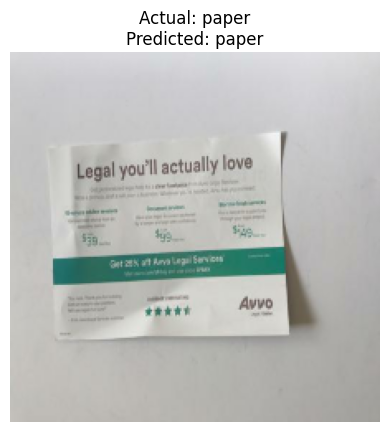

Image 2
Actual    : metal
Predicted : metal
------------------------------


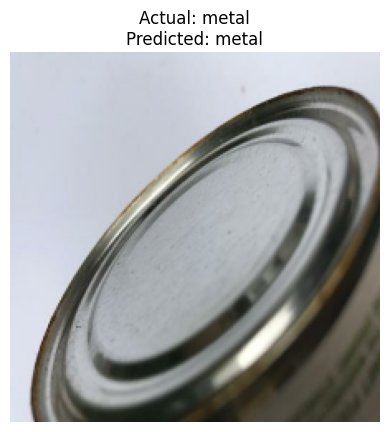

Image 3
Actual    : cardboard
Predicted : cardboard
------------------------------


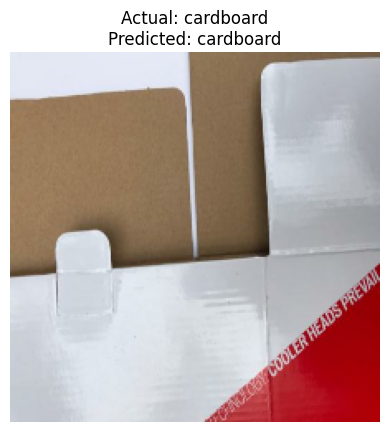

Image 4
Actual    : paper
Predicted : paper
------------------------------


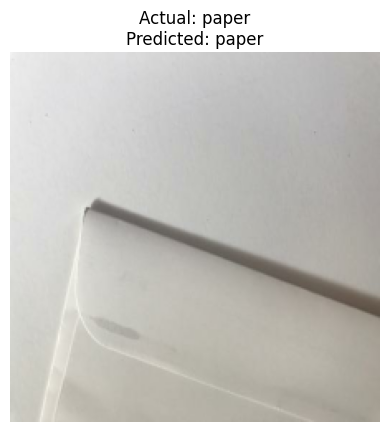

Image 5
Actual    : glass
Predicted : metal
------------------------------


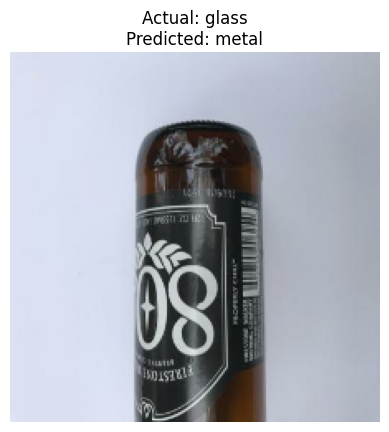

Image 6
Actual    : glass
Predicted : glass
------------------------------


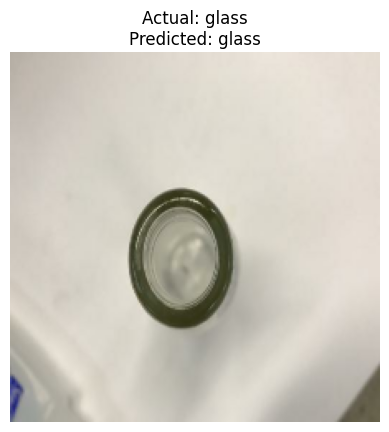

Image 7
Actual    : cardboard
Predicted : cardboard
------------------------------


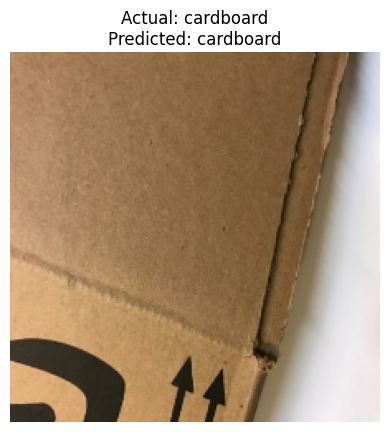

Image 8
Actual    : cardboard
Predicted : cardboard
------------------------------


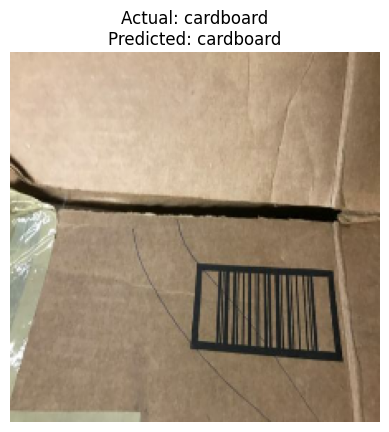

Image 9
Actual    : plastic
Predicted : plastic
------------------------------


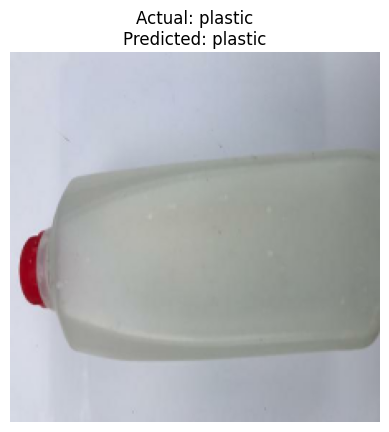

Image 10
Actual    : glass
Predicted : glass
------------------------------


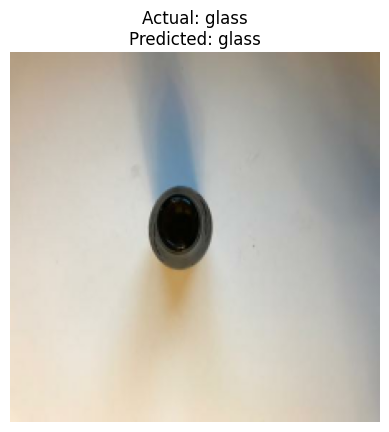

In [ ]:
for images,labels in val_ds.take(1):
  predicted= model.predict(images[:10])
  for i in range(10):

    predicted_label = np.argmax(predicted[i])
    actual_label = labels[i].numpy()

    print(f"Image {i+1}")
    print(f"Actual    : {class_names[actual_label]}")
    print(f"Predicted : {class_names[predicted_label]}")
    print("-" * 30)

    plt.imshow(images[i].numpy())
    plt.title(
        f"Actual: {class_names[actual_label]}\n"
        f"Predicted: {class_names[predicted_label]}"
    )
    plt.axis('off')
    plt.show()